In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [7]:
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True
)

datagen.fit(X_train)

In [8]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(28,28,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])

model.summary()

c:\Users\X280\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1
)

In [11]:
history = model.fit(

    datagen.flow(
        X_train,
        y_train_cat,
        batch_size=128
    ),

    epochs=20,

    validation_data=(
        X_test,
        y_test_cat
    ),

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.7351 - loss: 0.7275 - val_accuracy: 0.7744 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - accuracy: 0.8115 - loss: 0.5080 - val_accuracy: 0.8405 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 178ms/step - accuracy: 0.8346 - loss: 0.4512 - val_accuracy: 0.8528 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 178ms/step - accuracy: 0.8487 - loss: 0.4129 - val_accuracy: 0.8509 - val_loss: 0.4114 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 154ms/step - accuracy: 0.8596 - loss: 0.3861 - val_accuracy: 0.8869 - val_loss: 0.3091 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 125ms/step - accuracy: 0.8609 - loss: 0.3748 - val_accuracy: 0.8783 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.86

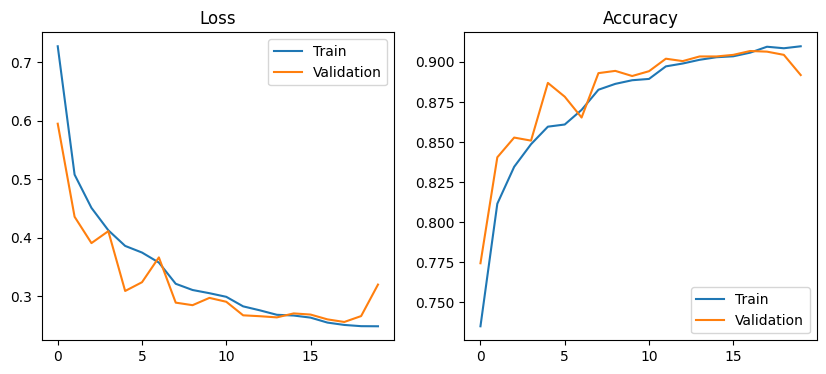

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.subplot(1,2,2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [13]:
loss, accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9064 - loss: 0.2561
Test Accuracy: 0.9064000248908997


In [14]:
loss, accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9064 - loss: 0.2561
Test Accuracy: 0.9064000248908997


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


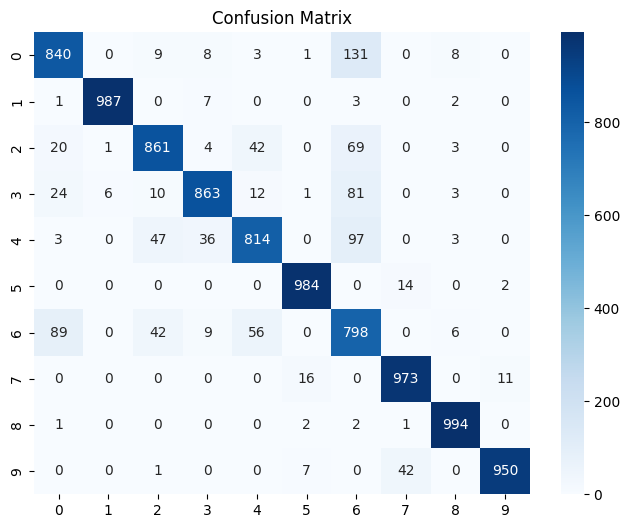

In [15]:
predictions = model.predict(X_test)

pred_labels = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_test,
    pred_labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

In [16]:
print(

    classification_report(
        y_test,
        pred_labels
    )
)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1000
           1       0.99      0.99      0.99      1000
           2       0.89      0.86      0.87      1000
           3       0.93      0.86      0.90      1000
           4       0.88      0.81      0.84      1000
           5       0.97      0.98      0.98      1000
           6       0.68      0.80      0.73      1000
           7       0.94      0.97      0.96      1000
           8       0.98      0.99      0.98      1000
           9       0.99      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



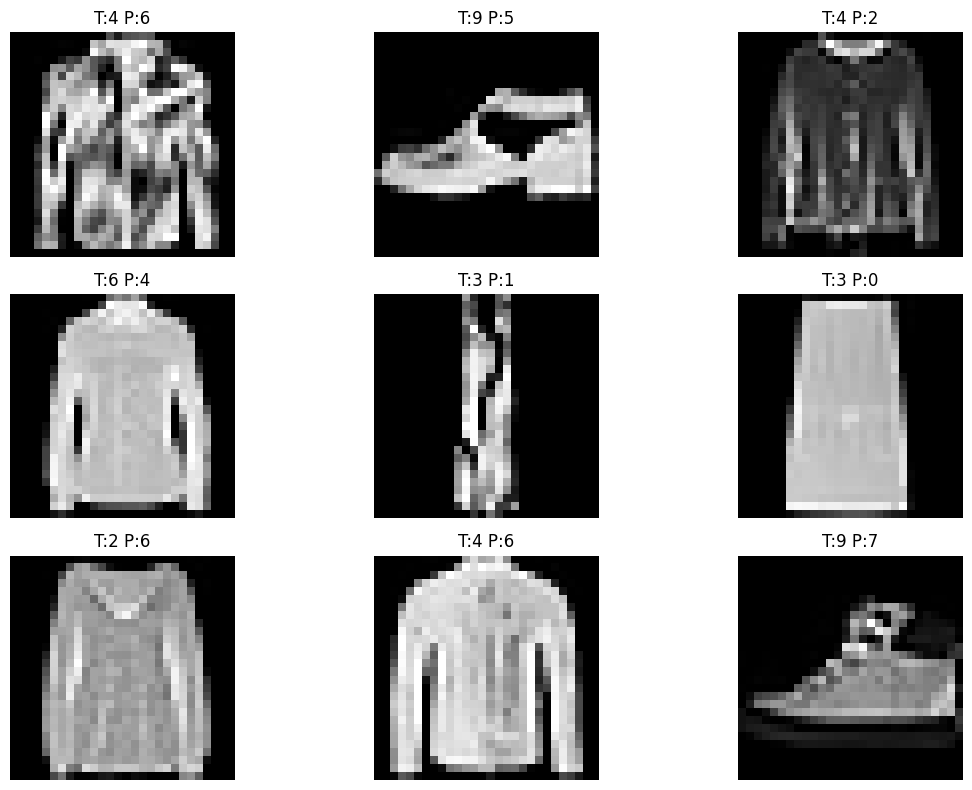

In [17]:
misclassified = np.where(
    pred_labels != y_test
)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(misclassified[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(
        X_test[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"T:{y_test[idx]} P:{pred_labels[idx]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()


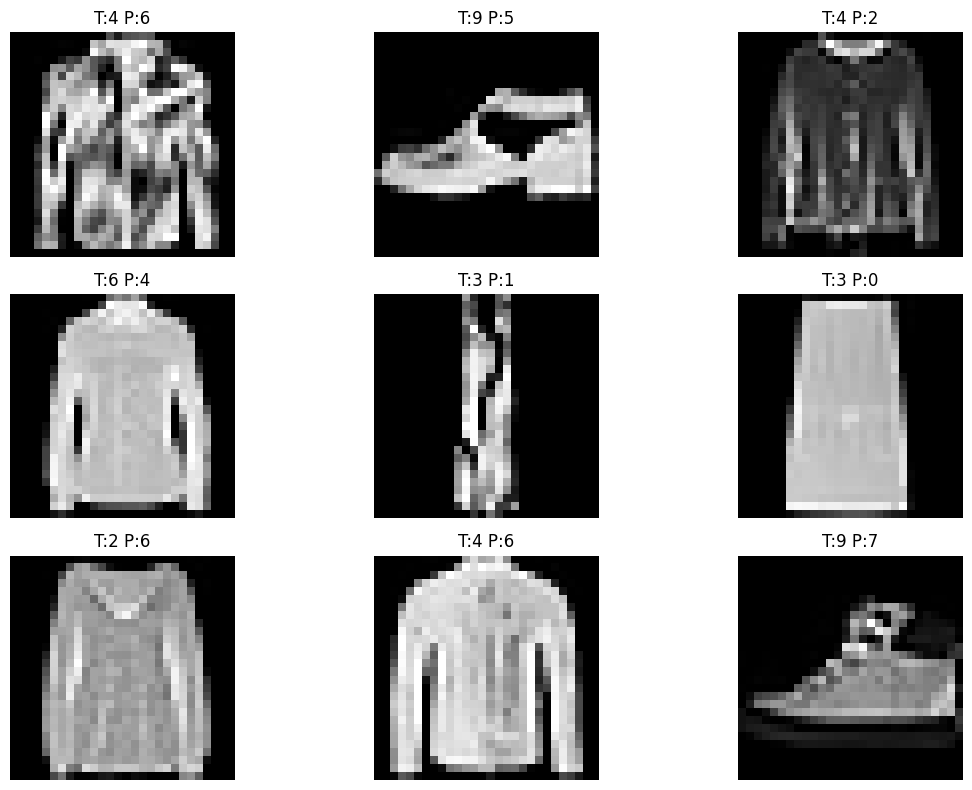

In [18]:
misclassified = np.where(
    pred_labels != y_test
)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(misclassified[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(
        X_test[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"T:{y_test[idx]} P:{pred_labels[idx]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [19]:
model.save(
    "fashion_mnist_cnn.keras"
)

print("Model Saved")

Model Saved


In [20]:
loaded_model = load_model(
    "fashion_mnist_cnn.keras"
)

print("Model Reloaded")

Model Reloaded


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


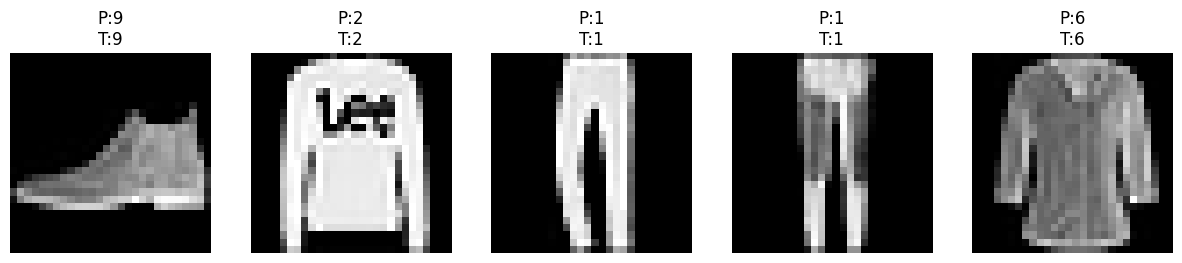

In [21]:
samples = X_test[:5]

predictions = loaded_model.predict(
    samples
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

plt.figure(figsize=(15,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        samples[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"P:{predicted_labels[i]}\nT:{y_test[i]}"
    )

    plt.axis('off')

plt.show()